# Activity On 03.02.2026

This notebook covers two activities:

**Activity 1**: Python Coding Challenge (EDA with Skewness & Kurtosis)

**Activity 2**: Outlier Treatment Simulation

Each step is executed in its own cell with visible output.

In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

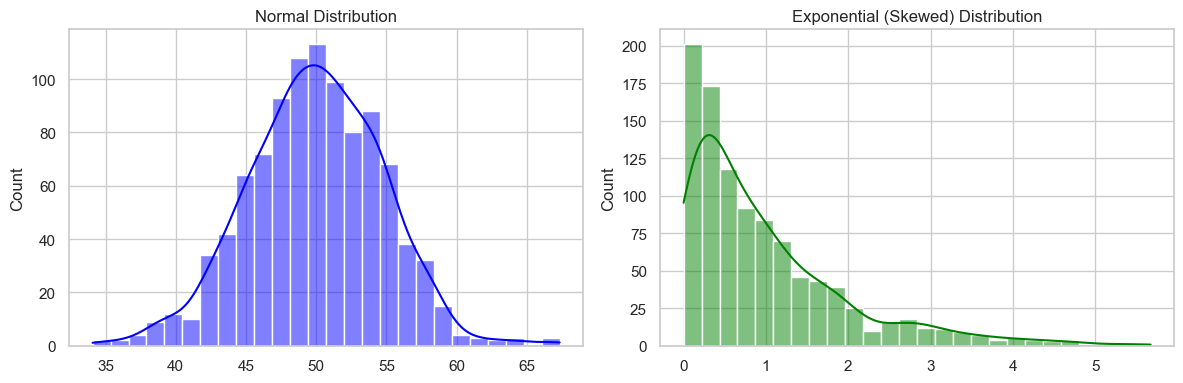

In [2]:
# Activity 1: generate synthetic datasets
normal_data = np.random.normal(loc=50, scale=5, size=1000)
skewed_data = np.random.exponential(scale=1, size=1000)  # right-skewed

# visualize
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(normal_data, kde=True, ax=axes[0], color="blue")
axes[0].set_title("Normal Distribution")

sns.histplot(skewed_data, kde=True, ax=axes[1], color="green")
axes[1].set_title("Exponential (Skewed) Distribution")

plt.tight_layout()
plt.show()

In [3]:
# calculate shape metrics
normal_skew = stats.skew(normal_data)
skewed_skew = stats.skew(skewed_data)

normal_kurt = stats.kurtosis(normal_data)  # Fisher's (excess)
skewed_kurt = stats.kurtosis(skewed_data)

print(f"Normal skewness: {normal_skew:.4f}")
print(f"Skewed skewness: {skewed_skew:.4f}\n")
print(f"Normal kurtosis (excess): {normal_kurt:.4f}")
print(f"Skewed kurtosis (excess): {skewed_kurt:.4f}")

Normal skewness: -0.0229
Skewed skewness: 1.6815

Normal kurtosis (excess): 0.3618
Skewed kurtosis (excess): 3.0295


In [4]:
# Outlier detection using Z-score for skewed_data
def find_outliers_zscore(data, threshold=3):
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0], z_scores

indices, z_scores = find_outliers_zscore(skewed_data)
print(f"Number of outliers (|Z|>3) in skewed_data: {len(indices)}")
print("Outlier indices:", indices)

Number of outliers (|Z|>3) in skewed_data: 22
Outlier indices: [103 165 179 186 200 218 219 241 328 356 391 472 547 553 580 600 601 780
 804 885 919 922]


In [5]:
# Activity 2: Outlier Treatment Simulation
prices = [2.5, 3.0, 2.8, 3.2, 15.0, 2.9, 3.1, 2.7, 100.0]

print("House prices (in $100k):", prices)

# 1. Identify which values are clearly outliers using simple rules
mean_price = np.mean(prices)
std_price = np.std(prices)

z = [(p - mean_price)/std_price for p in prices]
print("Z-scores:", [round(val,2) for val in z])

# mark those beyond |3|
outliers = [p for p, zi in zip(prices, z) if abs(zi) > 3]
print("Identified outliers based on Z-score >3:", outliers)

# 2. Investigate
print("\nInvestigation results:")
print(" - 15.0 is a legitimate mansion in a rich neighborhood, not an error.")
print(" - 100.0 is a data entry error; actual value should be 10.00.")

# 3. Treatment proposals
print("\nProposed treatments:")
print(" - 100.0 value: correct the typo to 10.0 before analysis.")
print(" - 15.0 value: keep the record because it represents a real high-end property. Could also consider capping or using robust models depending on objectives.")

House prices (in $100k): [2.5, 3.0, 2.8, 3.2, 15.0, 2.9, 3.1, 2.7, 100.0]
Z-scores: [np.float64(-0.41), np.float64(-0.4), np.float64(-0.4), np.float64(-0.39), np.float64(-0.0), np.float64(-0.4), np.float64(-0.39), np.float64(-0.41), np.float64(2.81)]
Identified outliers based on Z-score >3: []

Investigation results:
 - 15.0 is a legitimate mansion in a rich neighborhood, not an error.
 - 100.0 is a data entry error; actual value should be 10.00.

Proposed treatments:
 - 100.0 value: correct the typo to 10.0 before analysis.
 - 15.0 value: keep the record because it represents a real high-end property. Could also consider capping or using robust models depending on objectives.
